## Biweekly 20.01

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
from scipy.stats import chi2_contingency
from typing import Callable

def _resolve_project_root() -> Path:
    """locate project root containing config.py."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            print(candidate)
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')


PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# import config paths and helper functions
from config import (
    GENE_PATHS,
    SOURCE_PALETTE,
    VARIANT_PATHS,
    dedup_scores_by_variant,
    downsample_null_to_real,
)

# load gene-level summaries
gene_tables = {
    'clingen': pl.read_parquet(GENE_PATHS['clingen']),
    'background': pl.read_parquet(GENE_PATHS['background']),
    'background_null': pl.read_parquet(GENE_PATHS['background_null']),
    'clingen_null': pl.read_parquet(GENE_PATHS['clingen_null']),
}

for name, table in gene_tables.items():
    print(f'{name} gene shape: {table.shape}')

# load variant-level data with vg_predicted column
print('\nloading variant data (including vg_predicted)...')

# load clingen real variants
clingen_real = dedup_scores_by_variant(
    path=VARIANT_PATHS['clingen'],
    label='clingen',
    columns=['AF', 'vg_predicted'],  # include vg_predicted
    verbose=True,
)

# load clingen null variants
clingen_null_full = dedup_scores_by_variant(
    path=VARIANT_PATHS['clingen_null'],
    label='clingen_null',
    columns=['perm_AF'],
    verbose=True,
)

# downsample clingen null
clingen_gene_counts = gene_tables['clingen'].select(['gene_id', 'n_variants'])
clingen_null = downsample_null_to_real(clingen_null_full, clingen_gene_counts, seed=42)
print(f'  clingen_null after downsampling: {clingen_null.shape}')

# load background real variants
background_real = dedup_scores_by_variant(
    path=VARIANT_PATHS['background'],
    label='background',
    columns=['AF', 'vg_predicted'],  # include vg_predicted
    verbose=True,
)

# load background null variants
background_null_full = dedup_scores_by_variant(
    path=VARIANT_PATHS['background_null'],
    label='background_null',
    columns=['perm_AF'],
    verbose=True,
)

# downsample background null
background_gene_counts = gene_tables['background'].select(['gene_id', 'n_variants'])
background_null = downsample_null_to_real(background_null_full, background_gene_counts, seed=42)
print(f'  background_null after downsampling: {background_null.shape}')

# combine into variant_tables dict
variant_tables = {
    'clingen': clingen_real,
    'background': background_real,
    'background_null': background_null,
    'clingen_null': clingen_null,
}

print('\nvariant table shapes:')
for name, table in variant_tables.items():
    print(f'  {name}: {table.shape}')

# diagnostic: check columns
print('\ncolumns in variant_tables:')
for name, table in variant_tables.items():
    print(f'  {name}: {table.columns}')

# diagnostic: check vg_predicted
print('\nvg_predicted diagnostics:')
for name in ['clingen', 'background']:
    if 'vg_predicted' in variant_tables[name].columns:
        vg_stats = variant_tables[name]['vg_predicted'].describe()
        print(f'  {name} vg_predicted stats: {vg_stats}')
        non_zero = (variant_tables[name]['vg_predicted'] != 0).sum()
        print(f'  {name} non-zero vg_predicted: {non_zero}')
    else:
        print(f'  {name}: vg_predicted column MISSING!')


/Users/markus/in-silico-vg-analysis
clingen gene shape: (316, 66)
background gene shape: (349, 66)
background_null gene shape: (349, 68)
clingen_null gene shape: (316, 68)

loading variant data (including vg_predicted)...
  loaded clingen: (6450285, 37)
  after dedup: (1446682, 5)
  loaded clingen_null: (6499692, 33)
  after dedup: (1799166, 4)
  clingen_null after downsampling: (1439828, 4)
  loaded background: (7511454, 37)
  after dedup: (1461094, 5)
  loaded background_null: (7401834, 33)
  after dedup: (1795960, 4)
  background_null after downsampling: (1451874, 4)

variant table shapes:
  clingen: (1446682, 5)
  background: (1461094, 5)
  background_null: (1451874, 4)
  clingen_null: (1439828, 4)

columns in variant_tables:
  clingen: ['variant_id', 'gene_id', 'raw_score', 'AF', 'vg_predicted']
  background: ['variant_id', 'gene_id', 'raw_score', 'AF', 'vg_predicted']
  background_null: ['variant_id', 'gene_id', 'raw_score', 'perm_AF']
  clingen_null: ['variant_id', 'gene_id', 'r

In [2]:
# load AC (allele count) data from original TSV files
CLINGEN_TSV = Path(
    '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/'
    'dataset3_ClinGen/ClinGen_variants.tsv'
)
BG_TSV = Path(
    '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/'
    'dataset4_background/background_variants.tsv'
)


def _load_ac_table(path: str | Path, label: str) -> pl.DataFrame:
    """load ac from variant tsv.
    
    args:
        path (str | Path): tsv file path.
        label (str): dataset label for logging.
    
    returns:
        pl.DataFrame: variant_id, AC, gene_id.
    """
    file_path = Path(path)
    if not file_path.exists():
        raise FileNotFoundError(f'missing tsv for {label}: {file_path}')
    
    table = pl.read_csv(file_path, separator='\t')
    required = ['variant_id', 'AC', 'gene_tag']
    missing = [col for col in required if col not in table.columns]
    if missing:
        raise ValueError(f'missing columns in {file_path}: {missing}')
    
    # extract gene_id from gene_tag (format: ENSG00000123456|SYMBOL)
    table = (
        table
        .with_columns(
            pl.col('gene_tag').str.split('|').list.get(0).alias('gene_id')
        )
        .select(['variant_id', 'AC', 'gene_id'])
    )
    
    if table.is_empty():
        raise ValueError(f'no rows in tsv: {file_path}')
    
    return table


# load AC tables
ac_tables = {
    'clingen': _load_ac_table(path=CLINGEN_TSV, label='clingen'),
    'background': _load_ac_table(path=BG_TSV, label='background'),
}

# join AC values to real variant tables
matched_variants = {}
for name in ['clingen', 'background']:
    variants = variant_tables[name]
    
    if 'gene_id' not in variants.columns:
        raise ValueError(f'missing gene_id in {name} variants')
    
    ac_table = ac_tables[name].rename({'gene_id': 'gene_id_tsv', 'AC': 'ac'})
    joined = variants.join(ac_table, on='variant_id', how='left')
    
    missing_ac = joined.filter(pl.col('ac').is_null()).height
    coverage = 1 - (missing_ac / joined.height)
    print(f'{name} ac coverage: {coverage:.2%}')
    
    # drop the redundant gene_id_tsv column
    matched_variants[name] = joined.drop('gene_id_tsv')

print('\nmatched variant shapes (with AC):')
for name, table in matched_variants.items():
    print(f'  {name}: {table.shape}')

for name in ['clingen', 'background']:
    ac_stats = matched_variants[name]['ac'].describe()
    print(f'  {name} ac stats: {ac_stats}')
    print(f'  {name} ac nulls: {matched_variants[name]["ac"].null_count()}')
    print(f'  {name} sample ACs: {matched_variants[name]["ac"].head(10).to_list()}')

# diagnostic: check matched_variants columns and values
print('\nmatched_variants diagnostics:')
for name in ['clingen', 'background']:
    print(f'\n{name.upper()}:')
    print(f'  columns: {matched_variants[name].columns}')
    print(f'  shape: {matched_variants[name].shape}')
    
    # check raw_score
    if 'raw_score' in matched_variants[name].columns:
        rs_stats = matched_variants[name]['raw_score'].describe()
        print(f'  raw_score stats: {rs_stats}')
        print(f'  sample raw_scores: {matched_variants[name]["raw_score"].head(10).to_list()}')
        print(f'  non-zero raw_scores: {(matched_variants[name]["raw_score"] != 0).sum()}')
    else:
        print(f'  ERROR: raw_score column MISSING!')
    
    # check AC
    if 'ac' in matched_variants[name].columns:
        print(f'  sample ACs: {matched_variants[name]["ac"].head(10).to_list()}')
    else:
        print(f'  ERROR: ac column MISSING!')


clingen ac coverage: 100.00%
background ac coverage: 100.00%

matched variant shapes (with AC):
  clingen: (1448162, 6)
  background: (1465147, 6)
  clingen ac stats: shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 1.448162e6  │
│ null_count ┆ 0.0         │
│ mean       ┆ 399.697384  │
│ std        ┆ 5376.534693 │
│ min        ┆ 0.0         │
│ 25%        ┆ 1.0         │
│ 50%        ┆ 1.0         │
│ 75%        ┆ 3.0         │
│ max        ┆ 152410.0    │
└────────────┴─────────────┘
  clingen ac nulls: 0
  clingen sample ACs: [2, 1, 1, 1, 1, 1, 2, 1, 0, 6]
  background ac stats: shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 1.465147e6  │
│ null_count ┆ 0.0         │
│ mean       ┆ 505.499585  │
│ std        ┆ 6052.609642 │
│ min      

  clingen agg shape: (1263, 4), columns: ['gene_id', 'ac_bin', 'sum_sq_raw_score', 'dataset']
  clingen agg sample:
shape: (5, 4)
┌─────────────────┬────────┬──────────────────┬─────────┐
│ gene_id         ┆ ac_bin ┆ sum_sq_raw_score ┆ dataset │
│ ---             ┆ ---    ┆ ---              ┆ ---     │
│ str             ┆ str    ┆ f64              ┆ str     │
╞═════════════════╪════════╪══════════════════╪═════════╡
│ ENSG00000169862 ┆ AC=2   ┆ 0.331057         ┆ clingen │
│ ENSG00000164690 ┆ AC=1   ┆ 0.663126         ┆ clingen │
│ ENSG00000049618 ┆ AC=1   ┆ 0.209842         ┆ clingen │
│ ENSG00000065526 ┆ AC=2   ┆ 0.047469         ┆ clingen │
│ ENSG00000174748 ┆ AC>4   ┆ 0.215812         ┆ clingen │
└─────────────────┴────────┴──────────────────┴─────────┘
  background agg shape: (1396, 4), columns: ['gene_id', 'ac_bin', 'sum_sq_raw_score', 'dataset']
  background agg sample:
shape: (5, 4)
┌─────────────────┬────────┬──────────────────┬────────────┐
│ gene_id         ┆ ac_bin ┆ sum_sq

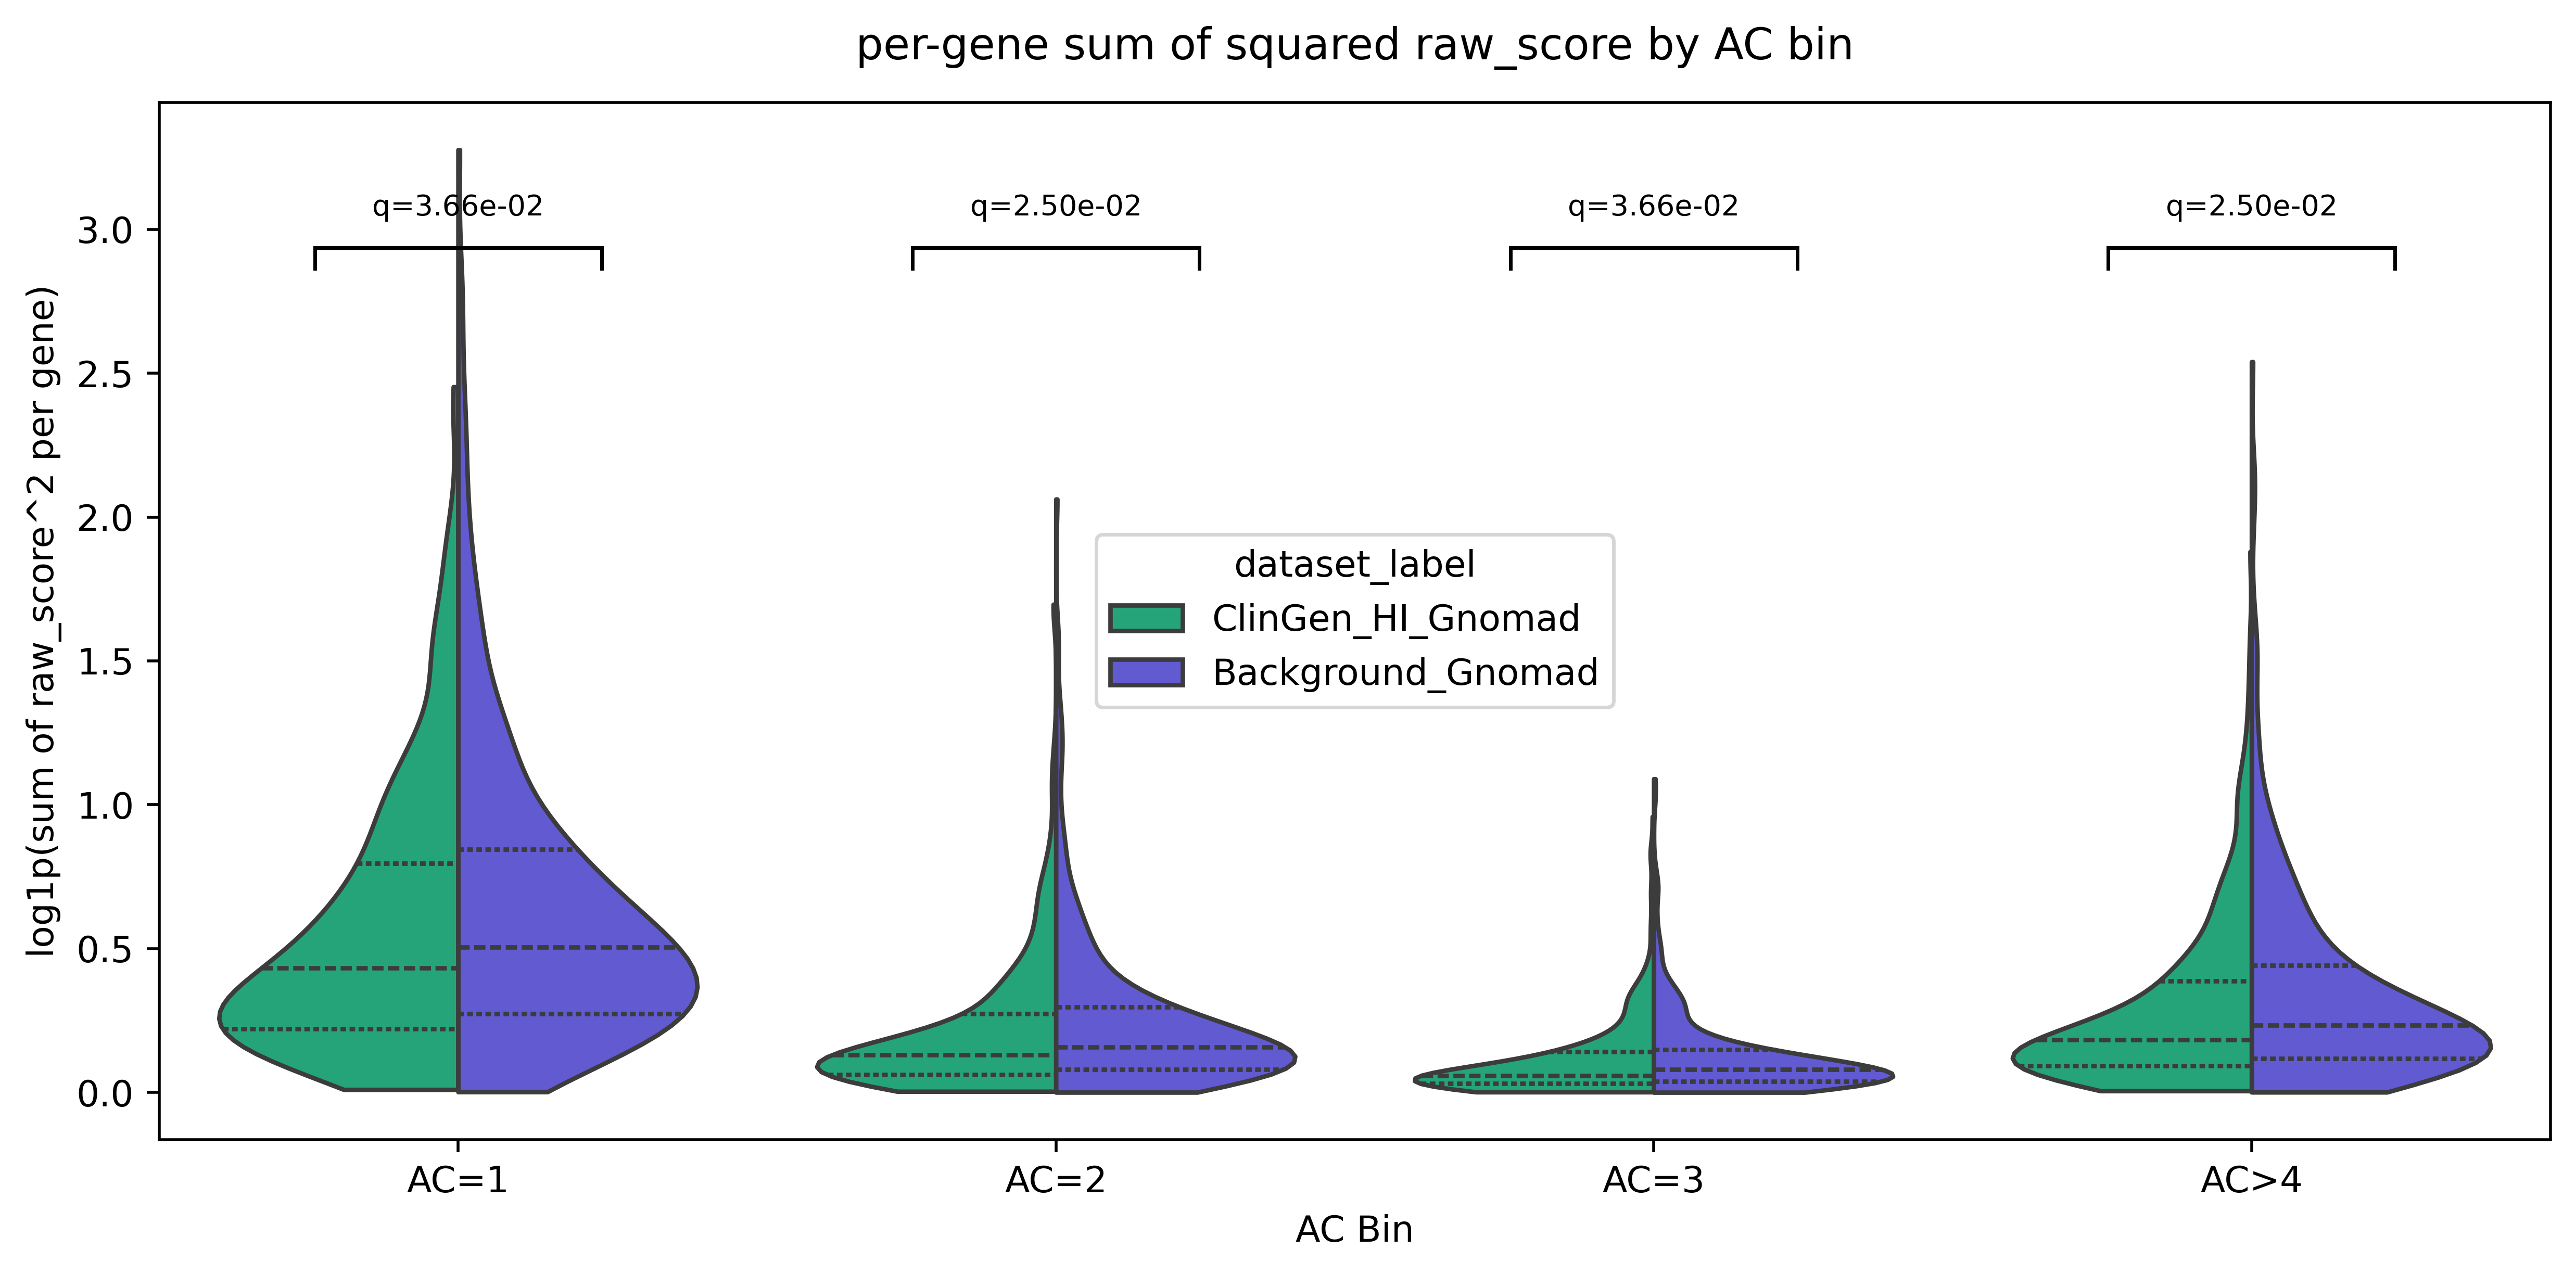

In [3]:
AC_BINS = {
    'AC=1': 1,
    'AC=2': 2,
    'AC=3': 3,
    'AC>4': 4,
}
AC_ORDER = list(AC_BINS.keys())


def _add_ac_bin(table: pl.DataFrame) -> pl.DataFrame:
    """assign ac bin labels for plotting.

    args:
        table (pl.DataFrame): variant table with ac.

    returns:
        pl.DataFrame: table with ac_bin column.
    """
    return table.with_columns(
        pl.when(pl.col('ac') == 1)
        .then(pl.lit('AC=1'))
        .when(pl.col('ac') == 2)
        .then(pl.lit('AC=2'))
        .when(pl.col('ac') == 3)
        .then(pl.lit('AC=3'))
        .when(pl.col('ac') > 4)
        .then(pl.lit('AC>4'))
        .otherwise(None)
        .alias('ac_bin')
    )


def _sum_sq_by_gene_ac(table: pl.DataFrame) -> pl.DataFrame:
    """aggregate sum of squared raw_score per gene and ac bin.

    args:
        table (pl.DataFrame): variant table with gene_id, raw_score, ac.

    returns:
        pl.DataFrame: per-gene aggregates by ac bin.
    """
    return (
        _add_ac_bin(table)
        .filter(pl.col('ac_bin').is_not_null())
        .group_by(['gene_id', 'ac_bin'])
        .agg(pl.col('raw_score').pow(2).sum().alias('sum_sq_raw_score'))
    )


def _sum_vg_by_gene_ac(table: pl.DataFrame) -> pl.DataFrame:
    """aggregate sum of vg_predicted per gene and ac bin.
    
    args:
        table (pl.DataFrame): variant table with gene_id, vg_predicted, ac.
    
    returns:
        pl.DataFrame: per-gene vg aggregates by ac bin.
    """
    return (
        _add_ac_bin(table)
        .filter(pl.col('ac_bin').is_not_null())
        .group_by(['gene_id', 'ac_bin'])
        .agg(pl.col('vg_predicted').sum().alias('sum_vg_predicted'))
    )


def _fdr_bh(p_values: dict[str, float]) -> dict[str, float]:
    labels = [k for k, p in p_values.items() if not np.isnan(p)]
    p = np.array([p_values[k] for k in labels], dtype=float)
    m = p.size
    if m == 0:
        return dict(p_values)

    # sort p ascending
    order = np.argsort(p)
    p_sorted = p[order]

    # BH adjust on sorted p's
    q_sorted = p_sorted * m / (np.arange(1, m + 1))

    # enforce monotonicity (non-decreasing q with increasing p)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    # map back to original label order
    q = np.empty_like(q_sorted)
    q[order] = q_sorted

    out = dict(p_values)
    for k, val in zip(labels, q.tolist(), strict=True):
        out[k] = float(val)
    return out


def _permutation_test_median(
    a: np.ndarray,
    b: np.ndarray,
    n_perm: int = 5000,
    seed: int = 0,
) -> float:
    """estimate two-sided permutation p-value on median difference.

    args:
        a (np.ndarray): first sample.
        b (np.ndarray): second sample.
        n_perm (int): number of permutations.
        seed (int): random seed.

    returns:
        float: permutation p-value.
    """
    rng = np.random.default_rng(seed)
    pooled = np.concatenate([a, b])
    n_a = a.size
    obs = np.abs(np.median(a) - np.median(b))
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        if np.abs(np.median(perm[:n_a]) - np.median(perm[n_a:])) >= obs:
            count += 1
    return (count + 1) / (n_perm + 1)


def _permutation_test_mean(
    a: np.ndarray,
    b: np.ndarray,
    n_perm: int = 5000,
    seed: int = 0,
) -> float:
    """estimate two-sided permutation p-value on mean difference.

    args:
        a (np.ndarray): first sample.
        b (np.ndarray): second sample.
        n_perm (int): number of permutations.
        seed (int): random seed.

    returns:
        float: permutation p-value.
    """
    rng = np.random.default_rng(seed)
    pooled = np.concatenate([a, b])
    n_a = a.size
    obs = np.abs(np.mean(a) - np.mean(b))
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        if np.abs(np.mean(perm[:n_a]) - np.mean(perm[n_a:])) >= obs:
            count += 1
    return (count + 1) / (n_perm + 1)


def _compute_raw_p_values(length_long: pd.DataFrame) -> dict[str, float]:
    """compute permutation p-values on median per ac bin.

    args:
        length_long (pd.DataFrame): long-form table with dataset and ac_bin.

    returns:
        dict[str, float]: raw p-values keyed by ac_bin label.
    """
    p_values: dict[str, float] = {}
    for ac_bin in AC_ORDER:
        subset = length_long[length_long['ac_bin'] == ac_bin]
        clingen_vals = subset.loc[
            subset['dataset'] == 'clingen', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        background_vals = subset.loc[
            subset['dataset'] == 'background', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        if clingen_vals.size == 0 or background_vals.size == 0:
            p_values[ac_bin] = float('nan')
            continue
        p_values[ac_bin] = _permutation_test_median(clingen_vals, background_vals)
    return p_values


def _compute_raw_p_values_mean(length_long: pd.DataFrame) -> dict[str, float]:
    """compute permutation p-values on mean per ac bin.

    args:
        length_long (pd.DataFrame): long-form table with dataset and ac_bin.

    returns:
        dict[str, float]: raw p-values keyed by ac_bin label.
    """
    p_values: dict[str, float] = {}
    for ac_bin in AC_ORDER:
        subset = length_long[length_long['ac_bin'] == ac_bin]
        clingen_vals = subset.loc[
            subset['dataset'] == 'clingen', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        background_vals = subset.loc[
            subset['dataset'] == 'background', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        if clingen_vals.size == 0 or background_vals.size == 0:
            p_values[ac_bin] = float('nan')
            continue
        p_values[ac_bin] = _permutation_test_mean(clingen_vals, background_vals)
    return p_values


def _compute_raw_p_values_mwu(length_long: pd.DataFrame) -> dict[str, float]:
    """compute mann-whitney p-values per ac bin.

    args:
        length_long (pd.DataFrame): long-form table with dataset and ac_bin.

    returns:
        dict[str, float]: raw p-values keyed by ac_bin label.
    """
    p_values: dict[str, float] = {}
    for ac_bin in AC_ORDER:
        subset = length_long[length_long['ac_bin'] == ac_bin]
        clingen_vals = subset.loc[
            subset['dataset'] == 'clingen', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        background_vals = subset.loc[
            subset['dataset'] == 'background', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        if clingen_vals.size == 0 or background_vals.size == 0:
            p_values[ac_bin] = float('nan')
            continue
        _, p_value = stats.mannwhitneyu(clingen_vals, background_vals, alternative='two-sided')
        p_values[ac_bin] = float(p_value)
    return p_values


def _bh_debug_print(raw_p: dict[str, float]) -> None:
    """print bh intermediate values for debugging.

    args:
        raw_p (dict[str, float]): raw p-values keyed by label.

    returns:
        None
    """
    labels = [label for label, value in raw_p.items() if not np.isnan(value)]
    p_arr = np.array([raw_p[label] for label in labels], dtype=float)
    if p_arr.size == 0:
        print('no valid p-values')
        return

    order = np.argsort(p_arr)
    p_sorted = p_arr[order]
    qprime = p_sorted * p_arr.size / (np.arange(1, p_arr.size + 1))
    qprime_clip = np.clip(qprime, 0.0, 1.0)
    q_sorted = np.minimum.accumulate(qprime_clip[::-1])[::-1]

    q_mapped = np.empty_like(q_sorted)
    q_mapped[order] = q_sorted

    df = pd.DataFrame({'label': labels, 'p_raw': p_arr}).set_index('label')
    df['p_sorted'] = pd.Series(p_sorted, index=[labels[i] for i in order])
    df['qprime_sorted'] = pd.Series(qprime_clip, index=[labels[i] for i in order])
    df['q_sorted_after_monotone'] = pd.Series(q_sorted, index=[labels[i] for i in order])
    df['q_final_mapped'] = pd.Series(q_mapped, index=labels)

    pd.set_option('display.float_format', '{:.3e}'.format)
    print('raw p-values (original order):')
    print(df['p_raw'])
    print('\nsorted p with qprime and monotone q:')
    print(df[['p_sorted', 'qprime_sorted', 'q_sorted_after_monotone']].dropna())
    print('\nfinal q mapped back to labels:')
    print(df['q_final_mapped'])


def _rank_biserial(a: np.ndarray, b: np.ndarray) -> float:
    """compute rank-biserial effect size from mann-whitney u.

    args:
        a (np.ndarray): first sample.
        b (np.ndarray): second sample.

    returns:
        float: rank-biserial effect size.
    """
    u_stat, _ = stats.mannwhitneyu(a, b, alternative='two-sided')
    n_a = a.size
    n_b = b.size
    if n_a == 0 or n_b == 0:
        return float('nan')
    return 1 - (2.0 * u_stat) / (n_a * n_b)


frames: list[pl.DataFrame] = []
for dataset in ['clingen', 'background']:
    table = matched_variants[dataset]
    missing = [col for col in ['gene_id', 'raw_score', 'ac'] if col not in table.columns]
    if missing:
        raise ValueError(f'missing columns in {dataset} table: {missing}')
    agg = _sum_sq_by_gene_ac(table).with_columns(pl.lit(dataset).alias('dataset'))
    print(f'  {dataset} agg shape: {agg.shape}, columns: {agg.columns}')
    print(f'  {dataset} agg sample:')
    print(agg.head())
    frames.append(agg)

sum_sq_long = pl.concat(frames, how='vertical').to_pandas()
sum_sq_long['sum_sq_raw_score_log1p'] = np.log1p(sum_sq_long['sum_sq_raw_score'])

DATASET_LABELS = {
    'clingen': 'ClinGen_HI_Gnomad',
    'background': 'Background_Gnomad',
}
DATASET_PALETTE = {
    DATASET_LABELS['clingen']: SOURCE_PALETTE['clingen'],
    DATASET_LABELS['background']: SOURCE_PALETTE['background'],
}

sum_sq_long['dataset_label'] = sum_sq_long['dataset'].map(DATASET_LABELS)

plt.figure(figsize=(10, 5), dpi=500)
ax = sns.violinplot(
    data=sum_sq_long,
    x='ac_bin',
    y='sum_sq_raw_score_log1p',
    hue='dataset_label',
    order=AC_ORDER,
    palette=DATASET_PALETTE,
    cut=0,
    density_norm='width',
    split=True,
    inner='quartile',
)

from matplotlib.lines import Line2D


def _add_bracket_annotation(
    ax: plt.Axes,
    x_center: float,
    y: float,
    text: str,
    width: float,
    lineheight: float,
) -> None:
    """draw bracket with text centered at the given x coordinate.

    args:
        ax (plt.Axes): axis to draw on.
        x_center (float): x location for the bracket.
        y (float): y location for the bracket.
        text (str): annotation text.
        width (float): bracket width in axis units.
        lineheight (float): bracket tick height.

    returns:
        None
    """
    left = x_center - (width / 2)
    right = x_center + (width / 2)
    ax.add_line(Line2D([left, right], [y, y], color='black', linewidth=1.0, clip_on=True))
    ax.add_line(
        Line2D([left, left], [y, y - lineheight], color='black', linewidth=1.0, clip_on=True)
    )
    ax.add_line(
        Line2D([right, right], [y, y - lineheight], color='black', linewidth=1.0, clip_on=True)
    )
    ax.text(x_center, y + (lineheight * 1.2), text, ha='center', va='bottom', fontsize=8)


raw_p = _compute_raw_p_values(sum_sq_long)
raw_p_mean = _compute_raw_p_values_mean(sum_sq_long)
raw_p_mwu = _compute_raw_p_values_mwu(sum_sq_long)
q_values = _fdr_bh(raw_p_mwu)

# debug bh inputs
print('raw_p (perm median):', raw_p)
print('raw_p (perm mean):', raw_p_mean)
print('raw_p (mann-whitney):', raw_p_mwu)
_bh_debug_print(raw_p_mwu)

# effect size
rank_biserial = {}
for ac_bin in AC_ORDER:
    subset = sum_sq_long[sum_sq_long['ac_bin'] == ac_bin]
    clingen_vals = subset.loc[
        subset['dataset'] == 'clingen', 'sum_sq_raw_score_log1p'
    ].to_numpy()
    background_vals = subset.loc[
        subset['dataset'] == 'background', 'sum_sq_raw_score_log1p'
    ].to_numpy()
    rank_biserial[ac_bin] = _rank_biserial(clingen_vals, background_vals)

print('rank-biserial (log1p):', rank_biserial)

n_bins = len(AC_ORDER)
x_centers_axes = [(idx + 0.5) / n_bins for idx in range(n_bins)]
y_bracket_ax = 0.86
y_text_ax = 0.885
width_ax = 0.12
tick_ax = 0.02

for idx, ac_bin in enumerate(AC_ORDER):
    left_ax = x_centers_axes[idx] - (width_ax / 2)
    right_ax = x_centers_axes[idx] + (width_ax / 2)

    ax.add_line(
        Line2D(
            [left_ax, right_ax],
            [y_bracket_ax, y_bracket_ax],
            transform=ax.transAxes,
            color='black',
            linewidth=1.0,
            clip_on=True,
        )
    )
    ax.add_line(
        Line2D(
            [left_ax, left_ax],
            [y_bracket_ax, y_bracket_ax - tick_ax],
            transform=ax.transAxes,
            color='black',
            linewidth=1.0,
            clip_on=True,
        )
    )
    ax.add_line(
        Line2D(
            [right_ax, right_ax],
            [y_bracket_ax, y_bracket_ax - tick_ax],
            transform=ax.transAxes,
            color='black',
            linewidth=1.0,
            clip_on=True,
        )
    )

    q_value = q_values[ac_bin]
    if np.isnan(q_value):
        label = 'q=n/a'
    else:
        label = f'q={q_value:.2e}'

    ax.text(
        x_centers_axes[idx],
        y_text_ax,
        label,
        ha='center',
        va='bottom',
        fontsize=8,
        transform=ax.transAxes,
        clip_on=True,
    )

ax.set_xlabel('AC Bin')
ax.set_ylabel('log1p(sum of raw_score^2 per gene)')
ax.set_title('per-gene sum of squared raw_score by AC bin', pad=12)
#ax.legend(title='dataset', loc='upper right')
plt.tight_layout()


  clingen vg agg shape: (1263, 4), columns: ['gene_id', 'ac_bin', 'sum_vg_predicted', 'dataset']
  clingen vg agg sample:
shape: (5, 4)
┌─────────────────┬────────┬──────────────────┬─────────┐
│ gene_id         ┆ ac_bin ┆ sum_vg_predicted ┆ dataset │
│ ---             ┆ ---    ┆ ---              ┆ ---     │
│ str             ┆ str    ┆ f64              ┆ str     │
╞═════════════════╪════════╪══════════════════╪═════════╡
│ ENSG00000136854 ┆ AC=2   ┆ 0.000011         ┆ clingen │
│ ENSG00000107796 ┆ AC>4   ┆ 0.000777         ┆ clingen │
│ ENSG00000099942 ┆ AC=3   ┆ 0.000004         ┆ clingen │
│ ENSG00000133895 ┆ AC=3   ┆ 0.000002         ┆ clingen │
│ ENSG00000171634 ┆ AC=2   ┆ 0.000001         ┆ clingen │
└─────────────────┴────────┴──────────────────┴─────────┘
  background vg agg shape: (1396, 4), columns: ['gene_id', 'ac_bin', 'sum_vg_predicted', 'dataset']
  background vg agg sample:
shape: (5, 4)
┌─────────────────┬────────┬──────────────────┬────────────┐
│ gene_id         ┆ ac_

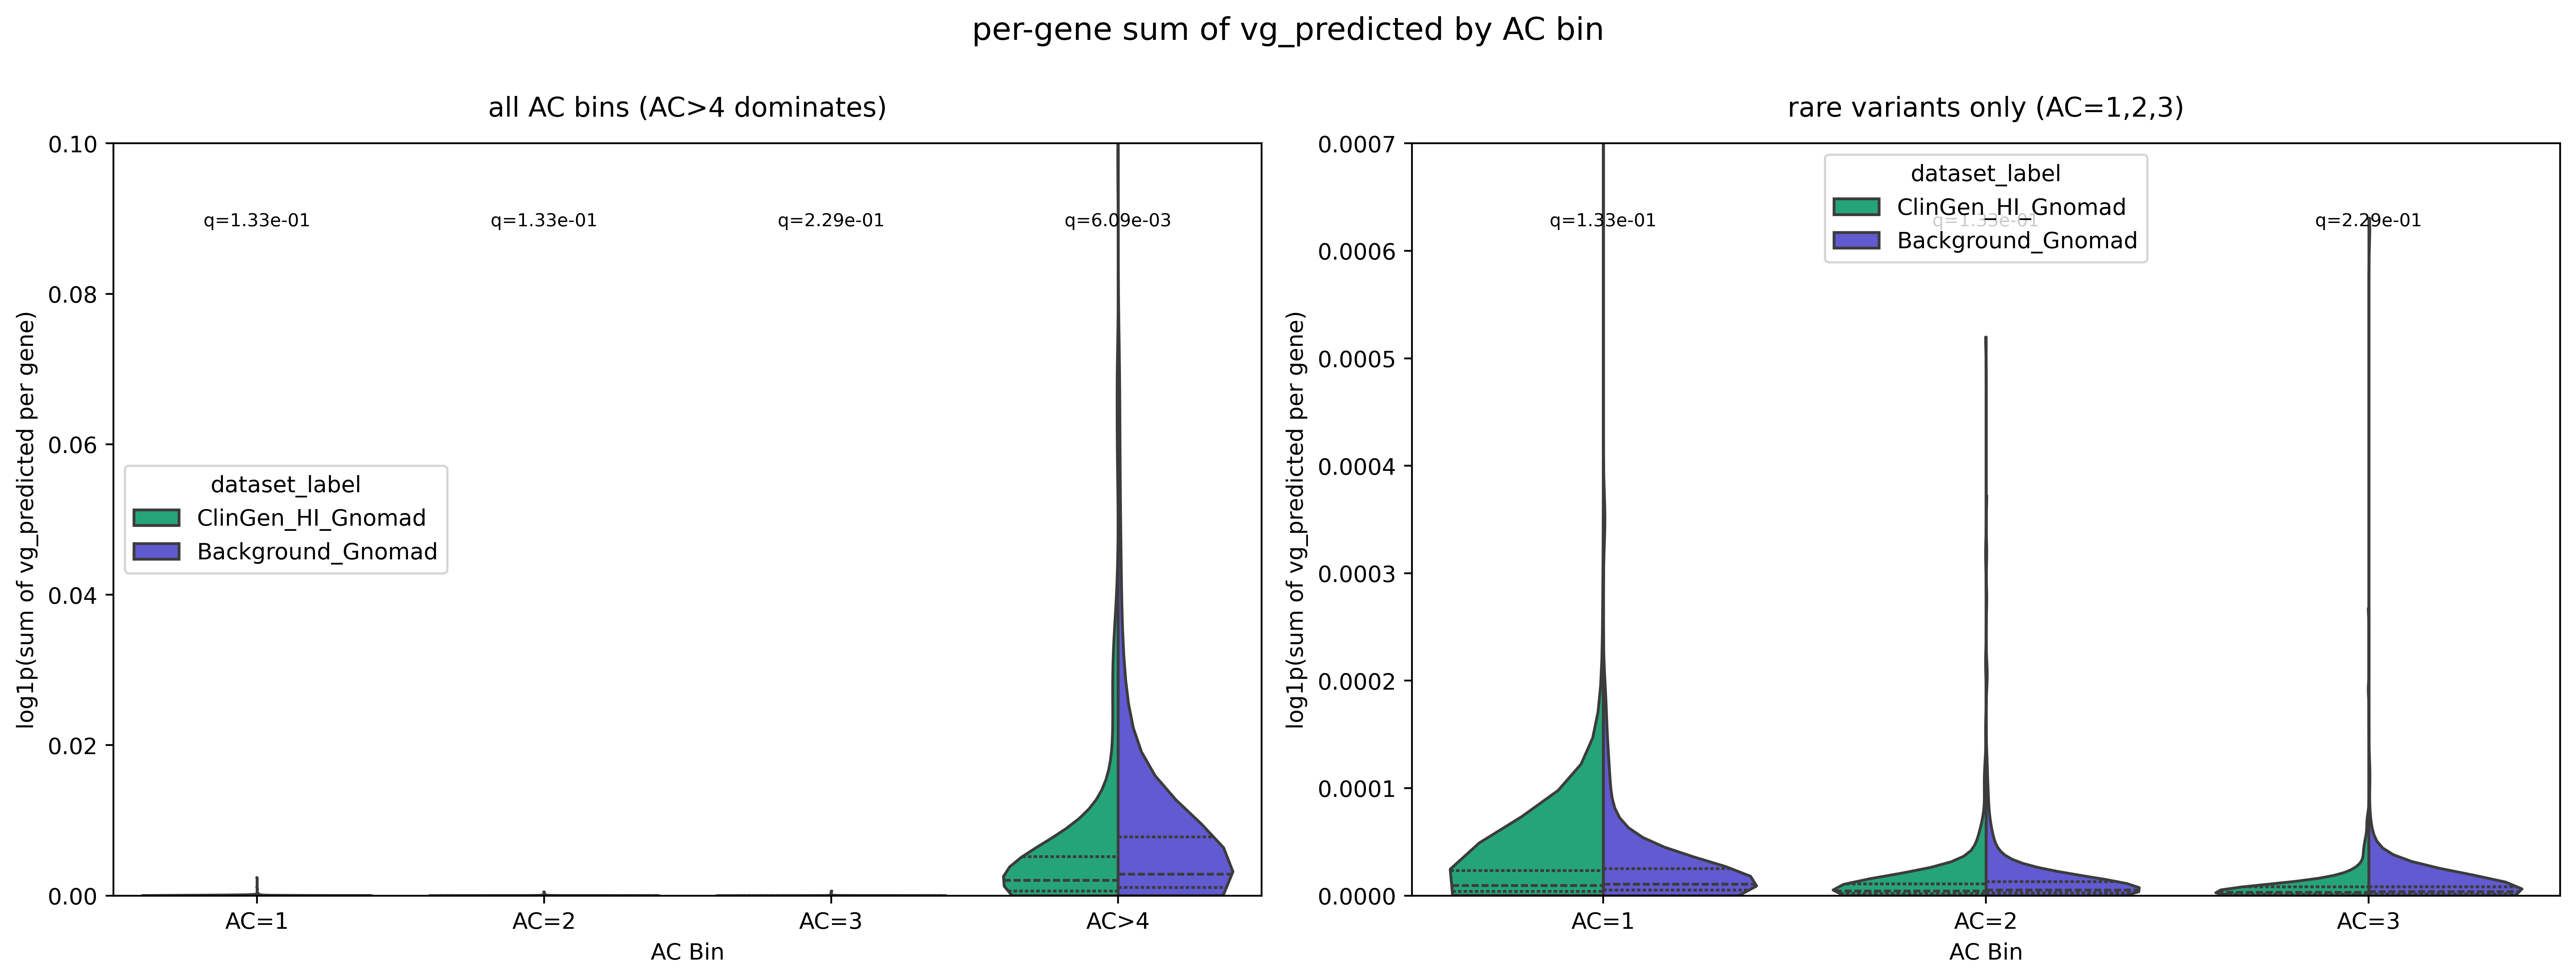

In [ ]:
# aggregate vg_predicted by gene and ac bin
vg_frames: list[pl.DataFrame] = []
for dataset in ['clingen', 'background']:
    table = matched_variants[dataset]
    missing = [col for col in ['gene_id', 'vg_predicted', 'ac'] if col not in table.columns]
    if missing:
        print(f'warning: {dataset} missing columns: {missing}')
        continue
    
    vg_agg = _sum_vg_by_gene_ac(table).with_columns(pl.lit(dataset).alias('dataset'))
    print(f'  {dataset} vg agg shape: {vg_agg.shape}, columns: {vg_agg.columns}')
    print(f'  {dataset} vg agg sample:')
    print(vg_agg.head())
    vg_frames.append(vg_agg)

if len(vg_frames) > 0:
    vg_long = pl.concat(vg_frames, how='vertical').to_pandas()
    vg_long['sum_vg_predicted_log1p'] = np.log1p(vg_long['sum_vg_predicted'])
    vg_long['dataset_label'] = vg_long['dataset'].map(DATASET_LABELS)
    
    # compute statistics
    def _compute_p_values_vg(vg_df: pd.DataFrame) -> dict[str, float]:
        p_vals = {}
        for ac_bin in AC_ORDER:
            subset = vg_df[vg_df['ac_bin'] == ac_bin]
            clingen_vals = subset.loc[
                subset['dataset'] == 'clingen', 'sum_vg_predicted_log1p'
            ].to_numpy()
            background_vals = subset.loc[
                subset['dataset'] == 'background', 'sum_vg_predicted_log1p'
            ].to_numpy()
            if clingen_vals.size == 0 or background_vals.size == 0:
                p_vals[ac_bin] = float('nan')
                continue
            _, p_value = stats.mannwhitneyu(clingen_vals, background_vals, alternative='two-sided')
            p_vals[ac_bin] = float(p_value)
        return p_vals
    
    raw_p_vg = _compute_p_values_vg(vg_long)
    q_values_vg = _fdr_bh(raw_p_vg)
    
    print('\nvg by ac bin statistics:')
    print('raw_p (mann-whitney):', raw_p_vg)
    print('q_values (fdr):', q_values_vg)
    
    # effect sizes
    rank_biserial_vg = {}
    for ac_bin in AC_ORDER:
        subset = vg_long[vg_long['ac_bin'] == ac_bin]
        clingen_vals = subset.loc[
            subset['dataset'] == 'clingen', 'sum_vg_predicted_log1p'
        ].to_numpy()
        background_vals = subset.loc[
            subset['dataset'] == 'background', 'sum_vg_predicted_log1p'
        ].to_numpy()
        rank_biserial_vg[ac_bin] = _rank_biserial(clingen_vals, background_vals)
    
    print('rank-biserial (vg, log1p):', rank_biserial_vg)
    
    # create figure with 2 subplots: all bins + rare bins only
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=500)
    
    # LEFT SUBPLOT: All AC bins
    ax_all = axes[0]
    sns.violinplot(
        data=vg_long,
        x='ac_bin',
        y='sum_vg_predicted_log1p',
        hue='dataset_label',
        order=AC_ORDER,
        palette=DATASET_PALETTE,
        cut=0,
        density_norm='width',
        split=True,
        inner='quartile',
        ax=ax_all,
    )
    ax_all.set_xlabel('AC Bin')
    ax_all.set_ylabel('log1p(sum of vg_predicted per gene)')
    ax_all.set_title('All AC bins', pad=12)
    ax_all.set_ylim(bottom=0.000, top=0.1)  # truncate y-axis to zoom in

    
    # add annotations for all bins
    n_bins_all = len(AC_ORDER)
    x_centers_all = [(idx + 0.5) / n_bins_all for idx in range(n_bins_all)]
    y_bracket_all = 0.86
    y_text_all = 0.885
    
    for idx, ac_bin in enumerate(AC_ORDER):
        q_value = q_values_vg[ac_bin]
        label = 'q=n/a' if np.isnan(q_value) else f'q={q_value:.2e}'
        ax_all.text(
            x_centers_all[idx],
            y_text_all,
            label,
            ha='center',
            va='bottom',
            fontsize=8,
            transform=ax_all.transAxes,
        )
    
    # RIGHT SUBPLOT: Only rare bins (AC=1, 2, 3)
    ax_rare = axes[1]
    rare_bins = ['AC=1', 'AC=2', 'AC=3']
    vg_rare = vg_long[vg_long['ac_bin'].isin(rare_bins)]
    
    sns.violinplot(
        data=vg_rare,
        x='ac_bin',
        y='sum_vg_predicted_log1p',
        hue='dataset_label',
        order=rare_bins,
        palette=DATASET_PALETTE,
        cut=0,
        density_norm='width',
        split=True,
        inner='quartile',
        ax=ax_rare,
    )
    ax_rare.set_xlabel('AC Bin')
    ax_rare.set_ylabel('log1p(sum of vg_predicted per gene)')
    ax_rare.set_title('Rare variants only (AC=1,2,3)', pad=12)
    ax_rare.set_ylim(bottom=0.000, top=0.0007)  # truncate y-axis to zoom in
    
    # add annotations for rare bins
    n_bins_rare = len(rare_bins)
    x_centers_rare = [(idx + 0.5) / n_bins_rare for idx in range(n_bins_rare)]
    
    for idx, ac_bin in enumerate(rare_bins):
        q_value = q_values_vg[ac_bin]
        label = 'q=n/a' if np.isnan(q_value) else f'q={q_value:.2e}'
        ax_rare.text(
            x_centers_rare[idx],
            y_text_all,
            label,
            ha='center',
            va='bottom',
            fontsize=8,
            transform=ax_rare.transAxes,
        )
    
    # add overall title
    fig.suptitle('per-gene sum of vg_predicted by AC bin', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print('no vg data available for plotting')


# What's new this week

1. We will change the naming for NULL sets to synthetic (SYNTH) and specify that our ClinGen dataset is Haploinsufficent. Therefore the new naming from here on will be. The reason to do this is because NULL is too vauge description for our usecase. 

- ClinGen_HI_Gnomad 
- ClinGen_HI_Synth
- Background_Gnomad
- Background_Sytnh

2. We will introduce VG scores to our Synthetic datasets. We do this by  comparing observed per-gene genetic variance to a permutation-based null distribution generated by randomly reassigning allele frequencies (AFs) from a global pool of observed variants keeping the distingtion between ClinGen_HI and Background datasets. Our new variants file have now new column vg_predicted_perm

3. For our gene level analysis we divide genes by different categories based on if the gene is singleton or doubleton or tripleton. We make extra annotations to our vairant level files on from AC values from intermediate variant files and calculate with aggregator module fractions of how many variants are affecting the gene level absolute score.

4. We calculate the gene-metrics correlations between whole groups, not just feature based

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
from scipy.stats import chi2_contingency
from typing import Callable

def _resolve_project_root() -> Path:
    """locate project root containing config.py."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            print(candidate)
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')


PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# import config paths and helper functions
from config import (
    GENE_PATHS,
    SOURCE_PALETTE,
    VARIANT_PATHS,
    dedup_scores_by_variant,
    downsample_null_to_real,
)

# load gene-level summaries
gene_tables = {
    'clingen': pl.read_parquet(GENE_PATHS['clingen']),
    'background': pl.read_parquet(GENE_PATHS['background']),
    'background_null': pl.read_parquet(GENE_PATHS['background_null']),
    'clingen_null': pl.read_parquet(GENE_PATHS['clingen_null']),
}

for name, table in gene_tables.items():
    print(f'{name} gene shape: {table.shape}')

# load variant-level data with vg_predicted column
print('\nloading variant data (including vg_predicted)...')

# load clingen real variants
clingen_real = dedup_scores_by_variant(
    path=VARIANT_PATHS['clingen'],
    label='clingen',
    columns=['AF', 'vg_predicted'],  # include vg_predicted
    verbose=True,
)

# load clingen null variants
clingen_null_full = dedup_scores_by_variant(
    path=VARIANT_PATHS['clingen_null'],
    label='clingen_null',
    columns=['perm_AF'],
    verbose=True,
)

# downsample clingen null
clingen_gene_counts = gene_tables['clingen'].select(['gene_id', 'n_variants'])
clingen_null = downsample_null_to_real(clingen_null_full, clingen_gene_counts, seed=42)
print(f'  clingen_null after downsampling: {clingen_null.shape}')

# load background real variants
background_real = dedup_scores_by_variant(
    path=VARIANT_PATHS['background'],
    label='background',
    columns=['AF', 'vg_predicted'],  # include vg_predicted
    verbose=True,
)

# load background null variants
background_null_full = dedup_scores_by_variant(
    path=VARIANT_PATHS['background_null'],
    label='background_null',
    columns=['perm_AF'],
    verbose=True,
)

# downsample background null
background_gene_counts = gene_tables['background'].select(['gene_id', 'n_variants'])
background_null = downsample_null_to_real(background_null_full, background_gene_counts, seed=42)
print(f'  background_null after downsampling: {background_null.shape}')

# combine into variant_tables dict
variant_tables = {
    'clingen': clingen_real,
    'background': background_real,
    'background_null': background_null,
    'clingen_null': clingen_null,
}

print('\nvariant table shapes:')
for name, table in variant_tables.items():
    print(f'  {name}: {table.shape}')

# diagnostic: check vg_predicted
print('\nvg_predicted diagnostics:')
for name in ['clingen', 'background']:
    if 'vg_predicted' in variant_tables[name].columns:
        vg_stats = variant_tables[name]['vg_predicted'].describe()
        print(f'  {name} vg_predicted stats:')
        print(vg_stats)
        non_zero = (variant_tables[name]['vg_predicted'] != 0).sum()
        print(f'  {name} non-zero vg_predicted: {non_zero}')
    else:
        print(f'  {name}: vg_predicted column MISSING!')

/Users/markus/in-silico-vg-analysis
clingen gene shape: (316, 66)
background gene shape: (349, 66)
background_null gene shape: (349, 68)
clingen_null gene shape: (316, 68)

loading variant data (including vg_predicted)...
  loaded clingen: (6450285, 37)
  after dedup: (1446682, 5)
  loaded clingen_null: (6499692, 33)
  after dedup: (1799166, 4)
  clingen_null after downsampling: (1439828, 4)
  loaded background: (7511454, 37)
  after dedup: (1461094, 5)
  loaded background_null: (7401834, 33)
  after dedup: (1795960, 4)
  background_null after downsampling: (1451874, 4)

variant table shapes:
  clingen: (1446682, 5)
  background: (1461094, 5)
  background_null: (1451874, 4)
  clingen_null: (1439828, 4)

vg_predicted diagnostics:
  clingen vg_predicted stats:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1.446682e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 0.0000